In [15]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_charge as yuc

yu.setpath('check_CDR')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
ens='b'
path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
[c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path)

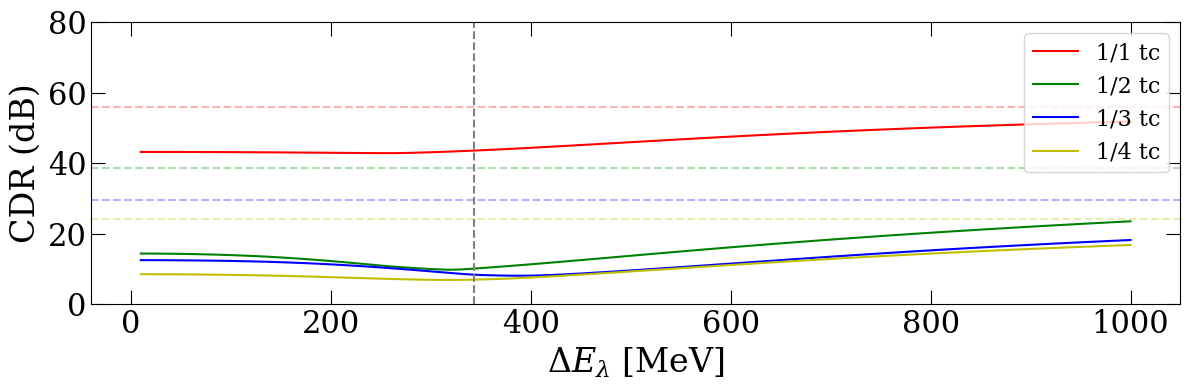

In [18]:
key='gS+'
tf2c3pt=key2tf2c3pt[key]
c2pt=c2pt_disc

n=2
def dE2lbd(dE):
    lbd0=dE*n
    return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)

def lbd2tf2ratio(dE):    
    lbd=dE2lbd(dE)
    tf2ratio={}
    for tf in tfs_conn:
        c3=tf2c3pt[tf]
        c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
        c2=(lbd**2)*c2pt[:,tf]
        tf2ratio[tf]=c3/c2[:,None]*yu.ens2aInv[ens]
    return tf2ratio

def getCDR(dE,downsampling=1):
    if dE==None:
        tf2ratio=key2tf2ratio[key]
    else:
        tf2ratio=lbd2tf2ratio(dE)
    
    tfmin=8; tcmin=3
    tfs=[tf for tf in tf2ratio.keys() if tf>=tfmin ]
    tf2tcs={tf:np.arange(tcmin,tf//2+1,downsampling) for tf in tfs}
    
    y=np.concatenate([tf2ratio[tf][:,tf2tcs[tf]] for tf in tfs],axis=1)
    cov=yu.jackmec(y)[-1]
    cdr=yu.getCDR(cov)
    
    return cdr

dEs=np.arange(10,1000+1,10)

fig,axs=yu.getFigAxs(1,1,Lrow=4,Lcol=12)
ax=axs[0,0]


cs=['r','g','b','y']
for ds in [1,2,3,4]:
    cdrs=[getCDR(dE/yu.ens2aInv[ens],downsampling=ds) for dE in dEs]
    ax.plot(dEs,cdrs,f'{cs[ds-1]}-',label=f'1/{ds} tc')
    yu.addRefLine(ax,getCDR(None,downsampling=ds),color=cs[ds-1],alpha=0.3)

ax.legend()
ax.set_xlabel(r'$\Delta E_{\lambda}$ [MeV]')
ax.set_ylabel('CDR (dB)')
ax.set_ylim([0,80])

yu.addRefLine(ax,342.9564513796705,hv='v')
yu.finalizePlot()